In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score, 
    roc_curve, confusion_matrix, f1_score
)
import warnings
warnings.filterwarnings('ignore')

X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    cv_auc = cross_val_score(model, X_train, y_train, 
                              cv=cv, scoring='roc_auc').mean()
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    test_f1  = f1_score(y_test, model.predict(X_test))
    
    results[name] = {'CV AUC': round(cv_auc, 4), 
                     'Test AUC': round(test_auc, 4),
                     'Test F1': round(test_f1, 4)}
    print(f"{name}: CV AUC={cv_auc:.4f} | Test AUC={test_auc:.4f} | F1={test_f1:.4f}")

results_df = pd.DataFrame(results).T
print("\n", results_df)

Logistic Regression: CV AUC=0.8461 | Test AUC=0.8424 | F1=0.6012
Random Forest: CV AUC=0.8233 | Test AUC=0.8279 | F1=0.5579
XGBoost: CV AUC=0.8235 | Test AUC=0.8146 | F1=0.5500

                      CV AUC  Test AUC  Test F1
Logistic Regression  0.8461    0.8424   0.6012
Random Forest        0.8233    0.8279   0.5579
XGBoost              0.8235    0.8146   0.5500


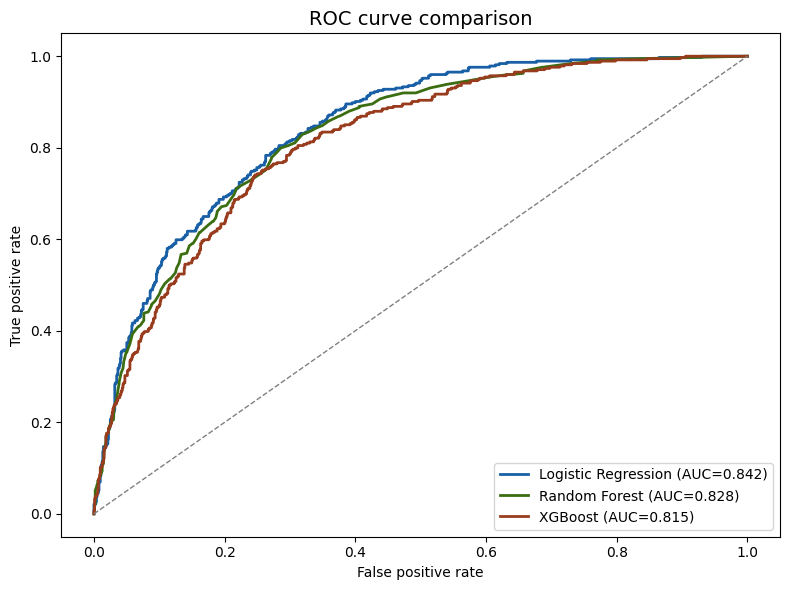

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#185FA5', '#3B6D11', '#993C1D']

for (name, model), color in zip(models.items(), colors):
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', 
            color=color, linewidth=2)

ax.plot([0,1],[0,1],'--', color='gray', linewidth=1)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve comparison', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'eval_metric': 'logloss', 'random_state': 42
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train, y_train, 
                            cv=3, scoring='roc_auc').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best AUC:", study.best_value)
print("Best params:", study.best_params)

# Retrain best model
best_xgb = XGBClassifier(**study.best_params, 
                          eval_metric='logloss', random_state=42)
best_xgb.fit(X_train, y_train)
final_auc = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1])
final_f1  = f1_score(y_test, best_xgb.predict(X_test))
print(f"Tuned XGBoost → AUC: {final_auc:.4f} | F1: {final_f1:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Best AUC: 0.8502589460733126
Best params: {'n_estimators': 191, 'max_depth': 4, 'learning_rate': 0.023788976112854215, 'subsample': 0.7481014943662457, 'colsample_bytree': 0.6780411323951373}
Tuned XGBoost → AUC: 0.8485 | F1: 0.5873


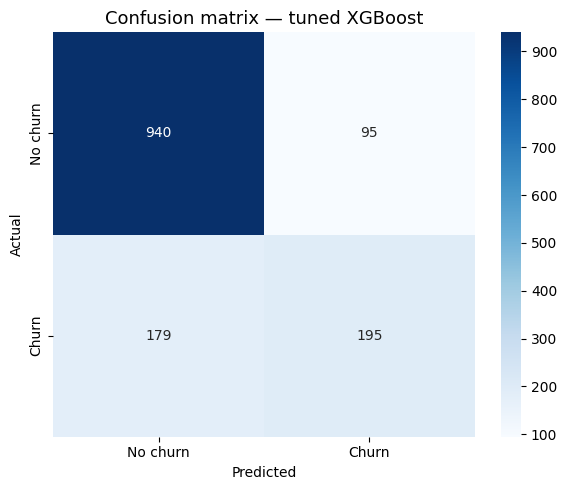

              precision    recall  f1-score   support

    No churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [5]:
y_pred = best_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No churn','Churn'],
            yticklabels=['No churn','Churn'], ax=ax)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.set_title('Confusion matrix — tuned XGBoost', fontsize=13)
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred, 
                             target_names=['No churn','Churn']))